# 1.1 線形モデル（3/4）分類と一般化線形モデル

**原典**: scikit-learn User Guide [1.1. Linear Models](https://scikit-learn.org/stable/modules/linear_model.html) の 1.1.11〜1.1.13（v1.9.1）

| | |
|---|---|
| **このノートで分かるようになること** | ・ロジスティック回帰が「回帰」なのに分類に使われる理由を説明できる<br>・正則化の強さ `C` と `l1_ratio` の意味、ソルバの選び方が分かる<br>・数え上げデータや正の値しか取らないデータに、GLM を使う理由を説明できる<br>・大規模・逐次的なデータを SGD で学習する方法を知る |
| **前提** | [1/4 最小二乗法と正則化](./01_linear_models_1_ols_regularization.ipynb)（正則化、L1 / L2） |
| **目安時間** | 60〜90 分 |

記号の意味は 1/4 と同じです（📖 ガイドの解説 / 💡 補足 / 📚 用語 / 🔢 数式を読む / 🎯 なぜ使うのか / 🏭 利用例 / 🕰️ 歴史 / 🧪 やってみよう / 👀 結果の読み方 / ⚠️ つまずきポイント）。

### 目次

1. 1.1.11 ロジスティック回帰
2. 1.1.12 一般化線形モデル（GLM）
3. 1.1.13 確率的勾配降下法（SGD）・パーセプトロン・Passive Aggressive
4. まとめ・確認クイズ

## セットアップ

実行済みの出力つきで保存しています。手元で動かす場合は上から順に実行してください。

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib  # グラフで日本語を表示するため

from sklearn import linear_model as lm

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)
plt.rcParams.update({"figure.figsize": (6, 3.6), "figure.dpi": 80, "axes.grid": True})
rng = np.random.RandomState(0)  # 乱数の種を固定（同じ結果を再現するため）

from scipy.special import expit   # シグモイド関数 1 / (1 + exp(-z))
from sklearn.datasets import load_iris, make_classification

---
## 1. ロジスティック回帰（1.1.11 Logistic regression）

**ねらい**: 直線の出力を「確率」に変換して分類する仕組みを理解し、正則化とソルバの選び方を身につける。

### 💡 補足: 線形回帰で「合格 / 不合格」を予測するとどうなるか

勉強時間から試験の合否（合格 = 1、不合格 = 0）を予測したいとします。1/4 の線形回帰をそのまま使うと、予測値は −0.3 や 1.4 のように **0〜1 の外にはみ出し**、確率として解釈できません。

そこで、直線の出力 $z = Xw + w_0$ を、**シグモイド関数**（ロジスティック関数）でつぶして 0〜1 に収めます。

$$\text{確率} = \frac{1}{1 + e^{-z}}$$

$z$ が大きいほど 1 に、小さいほど 0 に近づく S 字の曲線です。この確率が 0.5 を超えたら「合格」と判定します。

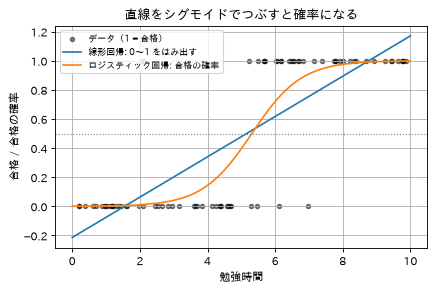

5 時間勉強したときの合格確率: 0.396 / 判定: 0


In [2]:
rng = np.random.RandomState(0)
hours = rng.uniform(0, 10, 80)                                     # 勉強時間
passed = (rng.rand(80) < expit(1.2 * (hours - 5))).astype(int)    # 5 時間前後で合格しやすくなる

lin = lm.LinearRegression().fit(hours[:, None], passed)
logi = lm.LogisticRegression().fit(hours[:, None], passed)

grid = np.linspace(0, 10, 200)[:, None]
plt.scatter(hours, passed, s=15, c="black", alpha=0.5, label="データ（1 = 合格）")
plt.plot(grid, lin.predict(grid), label="線形回帰: 0〜1 をはみ出す")
plt.plot(grid, logi.predict_proba(grid)[:, 1], label="ロジスティック回帰: 合格の確率")
plt.axhline(0.5, color="gray", ls=":", lw=1)
plt.xlabel("勉強時間"); plt.ylabel("合格 / 合格の確率"); plt.legend(fontsize=8)
plt.title("直線をシグモイドでつぶすと確率になる"); plt.show()

print("5 時間勉強したときの合格確率:", logi.predict_proba([[5]])[0, 1].round(3),
      "/ 判定:", logi.predict([[5]])[0])

### 📖 ガイドの解説

ロジスティック回帰は `LogisticRegression` に実装されています。名前に「回帰」と付きますが、scikit-learn / 機械学習の用語では**分類のための線形モデル**です。文献ではロジット回帰、最大エントロピー分類（MaxEnt）、対数線形分類器とも呼ばれます。1 回の試行で起こりうる結果の確率を、ロジスティック関数でモデル化します。

この実装は、2 値、One-vs-Rest、多項（multinomial）のロジスティック回帰に対応し、L1・L2・Elastic-Net の正則化を付けられます。

> 📖 **ノート: 正則化**　正則化は**既定で有効**です。機械学習では一般的ですが、統計学では一般的ではありません。正則化には数値計算を安定させる利点もあります。正則化なしにしたいときは、`C` を非常に大きな値にします。

> 📖 **ノート: GLM の特殊ケースとしてのロジスティック回帰**　ロジスティック回帰は、二項分布 / ベルヌーイ分布とロジットリンクを使う一般化線形モデル（GLM、→ 2 章）の特殊ケースです。出力の数値（予測確率）にしきい値（既定 0.5）を当てれば分類器になります。scikit-learn はこの形で実装しているので、目的変数にはカテゴリ（クラスのラベル）を渡します。

> 📚 **用語**
> - **ロジスティック関数（シグモイド関数）**: $\frac{1}{1 + e^{-z}}$。どんな実数 $z$ も 0〜1 の値に変換する S 字の関数。SciPy では `expit` という名前。
> - **オッズ（odds）**: 「起こる確率 ÷ 起こらない確率」。確率 0.8 ならオッズは 0.8 / 0.2 = 4（「4 対 1 で起こる」）。競馬や賭けで使われる考え方。
> - **ロジット（logit）**: オッズの対数 $\log \frac{p}{1 - p}$。ロジスティック関数の逆関数。**ロジスティック回帰は「ロジット（対数オッズ）が特徴の線形結合で表せる」と仮定したモデル**です。
> - **最大エントロピー分類（MaxEnt）**: 自然言語処理でよく使われた呼び名。「分かっている制約を満たす中で、最もあいまいさ（エントロピー）の大きい分布を選ぶ」という原理から、同じモデルが導かれる。
> - **One-vs-Rest（一対他）**: 多クラスを「クラス A か、それ以外か」の 2 値分類をクラスの数だけ作って解く方法。
> - **多項（multinomial）**: 全クラスの確率を 1 つのモデルで同時に扱う方法（1.1.11.2）。
> - **リンク関数**: 予測したい量（ここでは確率）を、線形結合の値に結びつける関数（2 章の GLM で詳しく扱う）。ロジスティック回帰ではロジットがリンク関数。

### 🎯 なぜ使うのか

- **確率を出せる**: 「合格か不合格か」だけでなく「合格の確率 72%」と答えられるので、しきい値を後から調整したり、リスクの大きさで優先順位をつけたりできます。
- **係数を解釈できる**: 係数は「特徴が 1 増えたとき、**対数オッズ**がいくら増えるか」を表します（下の実験で確かめます）。医療や金融など、判断の根拠を説明する必要がある分野で重宝されます。
- **速くて安定**: 大規模なデータでも学習でき、分類問題のベースラインとして定番です。

### 🏭 利用例

- **信用スコアリング**: 借り手の属性から、返済不能になる確率を予測する。
- **医療**: 検査値や生活習慣から、病気のリスク（発症確率）を推定する。疫学の研究では、係数から求めた**オッズ比**がよく報告されます。
- **Web 広告**: 広告がクリックされる確率（CTR）を予測する。膨大なデータを高速に学習できるので、長く主力モデルとして使われてきました。
- **スパム判定**: メールの単語などから、スパムである確率を求める。

### 🕰️ 歴史（参考情報）

- **1838 年**: ベルギーの数学者 **フェルフルスト（Verhulst）**が、人口の増え方（最初は急に増え、やがて頭打ちになる S 字）を表すために**ロジスティック関数**を考えました。
- **1944 年**: 統計学者 **バークソン（Joseph Berkson）**が、生物学の用量反応（薬の量と効き目の関係）の分析で「ロジット」という言葉とロジットモデルを導入しました。
- **1958 年**: **デビッド・コックス**が、2 値の結果を回帰で分析する方法としてロジスティック回帰を整理し、その後、統計学の標準的な手法になりました。

### 1.1.11.1 2 値の場合

📖 表記を簡単にするため、データ点 $i$ の目的変数 $y_i$ は $\{0, 1\}$ のどちらかとします。学習後、`predict_proba` は正例（クラス 1）の確率 $P(y_i = 1 \mid X_i)$ を次の式で予測します。

$$\hat{p}(X_i) = \operatorname{expit}(X_i w + w_0) = \frac{1}{1 + \exp(-X_i w - w_0)}$$

最適化問題としては、正則化項 $r(w)$ 付きの次のコスト関数を最小化します。

$$\min_{w} \frac{1}{S} \sum_{i=1}^n s_i \left( -y_i \log(\hat{p}(X_i)) - (1 - y_i) \log(1 - \hat{p}(X_i)) \right) + \frac{r(w)}{S C}$$

$s_i$ は利用者がサンプルごとに与える重みで（クラスの重みとサンプルの重みを掛け合わせたもの）、$S = \sum_i s_i$ はその合計です。

### 🔢 数式を読む: 確率の式

$$\hat{p}(X_i) = \frac{1}{1 + \exp(-X_i w - w_0)}$$

| 記号 | 意味 |
|---|---|
| $X_i$ | $i$ 番目のサンプルの特徴（1 行分） |
| $X_i w + w_0$ | 線形結合（1.1 の線形回帰の予測値と同じ形）。「クラス 1 らしさ」の点数 $z$ |
| $\exp(-z)$ | $z$ が大きいほど 0 に近づき、小さいほど大きくなる |
| $\hat{p}(X_i)$ | 点数 $z$ をシグモイドで 0〜1 に変換した、クラス 1 の確率 |

**日本語で読むと**: 線形の点数を計算し、それをシグモイド関数で確率に直す。点数が 0 なら確率 0.5、点数がプラスに大きいほど 1 に、マイナスに大きいほど 0 に近づく。

### 🔢 数式を読む: コスト関数

| 記号 | 意味 |
|---|---|
| $s_i$ | サンプル $i$ の重み（`sample_weight` と `class_weight` の積）。指定しなければすべて 1 |
| $S = \sum_i s_i$ | 重みの合計。これで割るので、前半は**重み付き平均** |
| $-y_i \log \hat{p} - (1 - y_i) \log(1 - \hat{p})$ | 1 件分の**対数損失**。正解が 1 なら $-\log \hat{p}$、正解が 0 なら $-\log(1 - \hat{p})$ だけが残る |
| $r(w)$ | 正則化の罰（下の表で選ぶ） |
| $C$ | 正則化の**逆の**強さ。大きいほど罰が軽い |

> 📚 **用語**: **対数損失（log loss）/ 交差エントロピー** — 予測確率が正解にどれだけ自信を持って合っていたかを測る損失。正解の確率を 0.9 と予測すれば罰は約 0.1、0.01 と予測すれば約 4.6 と、自信を持って外すほど急激に大きくなる。

### 💡 補足: この式を言葉で読む

- 前半は**対数損失**（log loss）です。正解が 1 のときは $-\log \hat{p}$、正解が 0 のときは $-\log(1 - \hat{p})$ を罰として足します。「自信満々に外す」（正解 1 なのに $\hat{p} = 0.01$ など）と、罰が非常に大きくなります。
- 後半 $r(w) / (SC)$ が正則化です。**`C` は割り算の側にある**ので、**`C` が大きいほど正則化が弱く**なります。Ridge / Lasso の `alpha` とは向きが逆です。

### 🧪 やってみよう: 式どおりに確率を計算しているか

In [3]:
X_b, y_b = make_classification(n_samples=200, n_features=5, random_state=0)
clf = lm.LogisticRegression().fit(X_b, y_b)

p_manual = expit(X_b @ clf.coef_[0] + clf.intercept_[0])      # ガイドの式で手計算
print("predict_proba と手計算が一致:", np.allclose(p_manual, clf.predict_proba(X_b)[:, 1]))
print("しきい値 0.5 で判定すると predict と一致:", ((p_manual > 0.5).astype(int) == clf.predict(X_b)).all())

predict_proba と手計算が一致: True
しきい値 0.5 で判定すると predict と一致: True


### 🧪 やってみよう: 係数を「オッズ比」として読む

最初の勉強時間の例で、係数の意味を確かめます。ロジスティック回帰では「対数オッズ = $w_0 + w_1 \times$ 勉強時間」なので、勉強時間が 1 時間増えると、**オッズが $e^{w_1}$ 倍**になるはずです。この $e^{w_1}$ を**オッズ比**と呼びます。

In [4]:
w1 = logi.coef_[0, 0]
def odds(h):
    p = logi.predict_proba([[h]])[0, 1]
    return p / (1 - p)

print(f"勉強時間の係数 w1 = {w1:.3f}  →  オッズ比 exp(w1) = {np.exp(w1):.3f}")
prob = lambda h: logi.predict_proba([[h]])[0, 1]
for h in [3, 5, 7]:
    print(f"{h}→{h + 1} 時間: 確率 {prob(h):.3f}→{prob(h + 1):.3f}（+{prob(h + 1) - prob(h):.3f}）"
          f"  / オッズ {odds(h):.3f}→{odds(h + 1):.3f}（×{odds(h + 1) / odds(h):.3f}）")

勉強時間の係数 w1 = 1.364  →  オッズ比 exp(w1) = 3.911
3→4 時間: 確率 0.041→0.143（+0.102）  / オッズ 0.043→0.168（×3.911）
5→6 時間: 確率 0.396→0.719（+0.323）  / オッズ 0.655→2.562（×3.911）
7→8 時間: 確率 0.909→0.975（+0.066）  / オッズ 10.022→39.195（×3.911）


👀 何時間から 1 時間増やしても、オッズはいつも同じ倍率（オッズ比）で増えています。一方、**確率**の増え方は、何時間の地点かで大きく違います（S 字の真ん中では急、端では緩やか）。

> ⚠️ **つまずきポイント**: ロジスティック回帰の係数は「確率がいくつ増えるか」ではなく「**対数オッズ**がいくつ増えるか」です。「係数 1.2 だから確率が 1.2 増える」とは読めません。医療論文などで「オッズ比 3.3」と書かれていたら、「その要因があるとオッズが 3.3 倍」という意味です。

### 📖 ガイドの解説: 正則化の選び方

正則化項 $r(w)$ は、引数 `C` と `l1_ratio` で次の 4 通りから選びます。

| 正則化 | 指定のしかた | $r(w)$ |
|---|---|---|
| なし | `C=np.inf` | $0$ |
| L1 | `l1_ratio=1` | $\lVert w \rVert_1$ |
| L2（既定） | `l1_ratio=0` | $\frac{1}{2}\lVert w \rVert_2^2 = \frac{1}{2} w^T w$ |
| Elastic-Net | `0 < l1_ratio < 1` | $\frac{1 - \rho}{2} w^T w + \rho \lVert w \rVert_1$ |

Elastic-Net の $\rho$（`l1_ratio`）は、L1 と L2 の強さの割合です。$\rho = 1$ なら L1、$\rho = 0$ なら L2 と同じです。

なお、クラスの重みとサンプルの重みの**大きさ**は、最適化問題に影響します。たとえば、サンプルの重みを定数 $b > 0$ 倍にするのは、（逆）正則化の強さ `C` を $b$ 倍にするのと同じです。

> ⚠️ **つまずきポイント（バージョンによる違い）**: 古い解説記事やこのガイドの旧版では、正則化の種類を `penalty="l1"` のように指定しています。scikit-learn 1.8 で **`penalty` 引数は非推奨**になり、1.10 で削除される予定です。今は `l1_ratio` と `C` で指定します。下のセルで、`penalty` を使うと警告が出ることを確かめます。

In [5]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    lm.LogisticRegression(penalty="l1", solver="saga", max_iter=2000).fit(X_b, y_b)
for w in caught:
    if w.category is FutureWarning:
        print("FutureWarning:", str(w.message)[:170], "...")

### 🧪 やってみよう: `C` を変えると係数はどうなるか

In [6]:
rows = [{"C": C, "係数のノルム ||w||": np.linalg.norm(lm.LogisticRegression(C=C, max_iter=5000).fit(X_b, y_b).coef_)}
        for C in [0.001, 0.01, 0.1, 1, 10, 1e6, np.inf]]
pd.DataFrame(rows).set_index("C")

,係数のノルム ||w||
C,
1.0000e-03,0.1235
1.0000e-02,0.6342
1.0000e-01,1.6696
1.0000e+00,3.0447
1.0000e+01,3.9198
1.0000e+06,4.1214
inf,4.1214


👀 `C` が大きいほど係数が大きくなります（正則化が弱まる）。`C=1e6` と `C=np.inf`（正則化なし）はほぼ同じ値で、「正則化なしは `C` を非常に大きくするのと同じ」というガイドの説明どおりです。

### 🧪 やってみよう: 「サンプルの重みを 5 倍」＝「`C` を 5 倍」

In [7]:
sw = np.random.RandomState(1).rand(len(y_b)) + 0.5    # 適当なサンプルの重み
a = lm.LogisticRegression(C=1.0, tol=1e-10, max_iter=5000).fit(X_b, y_b, sample_weight=sw * 5).coef_
b = lm.LogisticRegression(C=5.0, tol=1e-10, max_iter=5000).fit(X_b, y_b, sample_weight=sw).coef_
print("重み×5, C=1 :", a[0])
print("重み×1, C=5 :", b[0])
print("一致:", np.allclose(a, b, atol=1e-4))

重み×5, C=1 : [-1.065  -0.3309 -1.756  -1.5097  2.5766]
重み×1, C=5 : [-1.065  -0.3309 -1.756  -1.5097  2.5766]
一致: True


👀 一致しました。コスト関数の前半（損失）は重みの合計 $S$ で割って**平均**になっているので、重みを 5 倍しても変わりません。一方、後半（正則化）は $r(w) / (SC)$ なので、$S$ が 5 倍になると正則化が 1/5 に弱まります。これは `C` を 5 倍にしたのと同じです。

> ⚠️ **つまずきポイント**: クラスの偏りを補正するために `class_weight` を大きくすると、正則化の効き方も変わります。重みを変えたら、`C` も調整し直すのが安全です。

### 1.1.11.2 多項（multinomial）の場合

📖 2 値の場合を $K$ クラスに拡張したものが、多項ロジスティック回帰です。係数ベクトル 1 本の代わりに、係数行列 $W$ を使います。$W$ の各行 $W_k$ がクラス $k$ に対応し、クラス確率を次の式（ソフトマックス関数）で予測します。

$$\hat{p}_k(X_i) = \frac{\exp(X_i W_k + W_{0,k})}{\sum_{l=0}^{K-1} \exp(X_i W_l + W_{0,l})}$$

> 📖 **ノート**: 全クラスの確率の合計は 1 なので、$K - 1$ 本の重みベクトルだけでもモデルを表せます（残り 1 クラスの確率は自動的に決まる）。それでも scikit-learn は、実装を簡単にするためと、**クラスの順番に対して対称な**帰納バイアスを保つために、あえて $K$ 本の重みベクトルを使って過剰にパラメータ化しています。これは正則化があるときに特に重要です。正則化なしだと、この過剰なパラメータ化のせいで解が一意に定まらないことがあります。

> 📚 **用語**
> - **帰納バイアス（inductive bias）**: モデルが、見たことのないデータについて答えを出すときに前提としている「好み」や「仮定」。ここでは「どのクラスも対等に扱う」という好み。
> - **過剰パラメータ化（overparameterization）**: 必要な数より多くのパラメータを持たせること。同じ予測になるパラメータの組が複数あるので、答えが一意に決まらないことがある。
> - **一意（unique）**: 答えがただ 1 つに決まること。

### 🔢 数式を読む: ソフトマックス

$$\hat{p}_k(X_i) = \frac{\exp(X_i W_k + W_{0,k})}{\sum_{l=0}^{K-1} \exp(X_i W_l + W_{0,l})}$$

| 記号 | 意味 |
|---|---|
| $W_k$, $W_{0,k}$ | クラス $k$ 専用の係数と切片 |
| $X_i W_k + W_{0,k}$ | クラス $k$ の点数 $z_k$ |
| $\exp(z_k)$ | 点数を正の数に変換（点数が 1 上がると 2.7 倍になる） |
| 分母の $\sum_l$ | 全クラス分の合計。これで割ると合計がちょうど 1 になる |

**日本語で読むと**: クラスごとの点数を指数関数で正の「重み」にして、全体に対する割合を確率とする。

💡 **過剰パラメータ化の意味**: 全クラスの点数に同じ数を足しても、ソフトマックスの値は変わりません（分子と分母が同じ倍率で変わるため）。つまり $K$ 本の係数には「全部をずらしても同じ」という自由度があり、正則化なしでは答えが 1 つに決まりません。正則化があれば「係数が小さいほど良い」ので 1 つに決まります。1.2 の LDA で `coef_` がソルバによって変わったのも、同じ理由です。

### 💡 補足: ソフトマックスは「確率に変換する多クラス版のシグモイド」

クラスごとに点数 $z_k = X W_k + W_{0,k}$ を計算し、$e^{z_k}$ で全部を正の数にしてから、合計で割って**合計 1** にします。点数がいちばん高いクラスの確率がいちばん大きくなります。

In [8]:
X_i, y_i = load_iris(return_X_y=True)          # アヤメ 3 品種、特徴 4 個
multi = lm.LogisticRegression(max_iter=1000).fit(X_i, y_i)
print("coef_ の形:", multi.coef_.shape, "→ 3 クラス × 4 特徴（K 本の重み）")

scores = X_i @ multi.coef_.T + multi.intercept_
softmax = np.exp(scores) / np.exp(scores).sum(axis=1, keepdims=True)
print("ソフトマックスの手計算と predict_proba が一致:", np.allclose(softmax, multi.predict_proba(X_i)))
print("最初の花の確率:", multi.predict_proba(X_i[:1]).round(3), "合計 =", multi.predict_proba(X_i[:1]).sum())

coef_ の形: (3, 4) → 3 クラス × 4 特徴（K 本の重み）
ソフトマックスの手計算と predict_proba が一致: True
最初の花の確率: [[0.982 0.018 0.   ]] 合計 = 0.9999999999999999


📖 **数式の補足（Mathematical details）**: ラベル $y_i \in \{1, \dots, K\}$ のとき、最適化の目的関数は次のとおりです。$[P]$ はアイバーソン括弧で、$P$ が偽なら 0、真なら 1 です。重み $s_{ik}$ とその合計 $S$ は 2 値の場合と同じ意味です。

$$\min_W -\frac{1}{S} \sum_{i=1}^n \sum_{k=0}^{K-1} s_{ik} [y_i = k] \log(\hat{p}_k(X_i)) + \frac{r(W)}{S C}$$

正則化 $r(W)$ も 2 値の場合と同じく 4 通りで、係数行列全体に対して L1 なら全要素の絶対値の和、L2 なら全要素の二乗和の半分（フロベニウスノルム）になります。

### 1.1.11.3 ソルバ

📖 `LogisticRegression` のソルバは `lbfgs`, `liblinear`, `newton-cg`, `newton-cholesky`, `sag`, `saga` の 6 つです。対応する正則化と機能は次のとおりです。

| | lbfgs | liblinear | newton-cg | newton-cholesky | sag | saga |
|---|---|---|---|---|---|---|
| L2 | ✅ | ✅ | ✅ | ✅ | ✅ | ✅ |
| L1 | — | ✅ | — | — | — | ✅ |
| Elastic-Net | — | — | — | — | — | ✅ |
| 正則化なし | ✅ | — | ✅ | ✅ | ✅ | ✅ |
| 多項（multinomial） | ✅ | — | ✅ | ✅ | ✅ | ✅ |
| 切片も罰してしまう（望ましくない） | — | ✅ | — | — | — | — |
| 大規模データで速い | — | — | — | — | ✅ | ✅ |
| スケールをそろえていないデータに強い | ✅ | ✅ | ✅ | ✅ | — | — |

**選び方の目安**

- 既定は、堅牢な `lbfgs`。
- `n_samples >> n_features`（サンプルが特徴よりずっと多い）なら `newton-cholesky`。高い精度（小さな `tol`）まで到達できる。
- 大規模データなら、たいてい `saga` が `lbfgs` より速い（特に精度をそこまで求めない＝大きな `tol` のとき）。
- さらに大きなデータなら、`SGDClassifier(loss="log_loss")` も候補。もっと速いかもしれないが、調整が必要（→ 3 章）。

> 📚 **用語**
> - **ソルバ**: 最小化問題を実際に解く計算方法。同じ問題でも、解き方によって速さ・対応できる正則化・メモリ使用量が違う。
> - **勾配**: 関数が最も急に増える向きと、その急さ。最小化では、勾配の逆向きに進む。
> - **ヘッセ行列**: 関数の「曲がり具合」（2 階微分）をまとめた行列。これを使うと、谷底への距離まで見積もれるので少ない反復で収束するが、計算とメモリの負担が大きい。
> - **ニュートン法 / 準ニュートン法**: ヘッセ行列を使って一気に谷底へ近づく方法 / ヘッセ行列を直接計算せず、勾配の履歴から近似する方法（`lbfgs` はこちら）。
> - **スケールをそろえる**: 特徴ごとの値の大きさ（単位）を、標準化などでそろえること。`sag` / `saga` はそろっていないと遅くなる。

> 🕰️ **歴史（参考情報）**: `liblinear` は、国立台湾大学の**林智仁（Chih-Jen Lin）**らのグループが開発した大規模線形分類のライブラリで、2008 年に論文（Fan ら、ガイドの参考文献）が発表されました。同じグループの `LIBSVM` とともに、機械学習の実務で広く使われてきました。

### 🧪 やってみよう: 表が本当か、全部の組み合わせで確かめる

In [9]:
Xs_b = (X_b - X_b.mean(0)) / X_b.std(0)       # 標準化（sag / saga のため）
settings = {"L2": dict(l1_ratio=0.0), "L1": dict(l1_ratio=1.0),
            "Elastic-Net": dict(l1_ratio=0.5), "正則化なし": dict(C=np.inf)}
table = {}
for solver in ["lbfgs", "liblinear", "newton-cg", "newton-cholesky", "sag", "saga"]:
    table[solver] = {}
    for label, kw in settings.items():
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                lm.LogisticRegression(solver=solver, max_iter=300, **kw).fit(Xs_b, y_b)
            table[solver][label] = "✅"
        except ValueError:
            table[solver][label] = "— (エラー)"
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")   # 収束の警告は表示しない（対応しているかだけを見る）
            lm.LogisticRegression(solver=solver, max_iter=300).fit(X_i, y_i)
        table[solver]["多クラス"] = "✅"
    except ValueError:
        table[solver]["多クラス"] = "— (エラー)"
pd.DataFrame(table)

,lbfgs,liblinear,newton-cg,newton-cholesky,sag,saga
L2,✅,✅,✅,✅,✅,✅
L1,— (エラー),✅,— (エラー),— (エラー),— (エラー),✅
Elastic-Net,— (エラー),— (エラー),— (エラー),— (エラー),— (エラー),✅
正則化なし,✅,— (エラー),✅,✅,✅,✅
多クラス,✅,— (エラー),✅,✅,✅,✅


👀 ガイドの表と**完全に一致**しました。対応していない組み合わせは、黙って別の設定で動くのではなく、`ValueError` で止まります。

📖 **参考文献**: `lbfgs` は SciPy の `minimize`、`liblinear` は Fan ら（2008）と Yu ら（2011）、`sag` は Schmidt ら（2017）、`saga` は Defazio ら（2014）で説明されています。

#### 1.1.11.3.1 ソルバの違い（Differences between solvers）

📖 `solver="liblinear"` の `LogisticRegression` や `LinearSVC` と、外部の liblinear ライブラリを直接使った場合とで、スコアが違うことがあります。`fit_intercept=False` で、学習した `coef_` または予測するデータが 0 のときです。決定関数（`decision_function`）の値がちょうど 0 のサンプルを、`LogisticRegression` と `LinearSVC` は負クラスと予測し、liblinear は正クラスと予測するためです。ただし、`fit_intercept=False` で決定関数が 0 のサンプルが多いモデルは、適合不足の悪いモデルである可能性が高く、`fit_intercept=True` にして `intercept_scaling` を大きくすることが勧められています。

**📖 ソルバの詳細（Solvers' details）**

- **liblinear**: 座標降下法を使い、scikit-learn に同梱の C++ ライブラリ LIBLINEAR を利用します。この座標降下法では**本当の多項モデルは学習できません**。多クラス問題で使いたい場合は、One-vs-Rest 方式 `OneVsRestClassifier(LogisticRegression(solver="liblinear"))` を使います。多項損失を最小化するほうが、One-vs-Rest よりも**確率の較正が良い**傾向があります。L1 正則化で係数がすべて 0 にならない `C` の下限は、`sklearn.svm.l1_min_c` で計算できます。
- **lbfgs / newton-cg / newton-cholesky / sag**: L2 正則化か正則化なしにだけ対応し、高次元データで速く収束することがあります。これらと `saga` は、本当の多項ロジスティック回帰を学習します。
- **sag**: 確率的平均勾配降下法（Stochastic Average Gradient）。サンプル数も特徴数も大きいとき、ほかのソルバより速くなります。
- **saga**: `sag` の変種で、微分できない L1 正則化（`l1_ratio=1`）にも対応します。スパースな多項ロジスティック回帰の第一候補で、**Elastic-Net（0 < `l1_ratio` < 1）に対応する唯一のソルバ**です。
- **lbfgs**: 準ニュートン法の一種で、BFGS 法を近似します。さまざまな学習データに対応できるので既定になっています。ただし、**スケールがそろっていないデータ**や、**まれなカテゴリを one-hot 化した特徴**を含むデータでは性能が落ちます。
- **newton-cholesky**: ヘッセ行列を計算して連立方程式を解く、厳密なニュートン法です。`n_samples >> n_features` のときにとても良い選択で、高い精度まで到達できます。ただし L2 正則化にしか対応せず、ヘッセ行列を明示的に作るので、**メモリ使用量が `n_features` と `n_classes` の二乗に比例**します。

### 🧪 やってみよう: liblinear で多クラスを扱う

In [10]:
from sklearn.multiclass import OneVsRestClassifier
try:
    lm.LogisticRegression(solver="liblinear").fit(X_i, y_i)
except ValueError as e:
    print("そのまま:", str(e)[:90], "...")
ovr = OneVsRestClassifier(lm.LogisticRegression(solver="liblinear")).fit(X_i, y_i)
print("OneVsRest で包むと学習できる。精度:", round(ovr.score(X_i, y_i), 3),
      "/ 多項モデル (lbfgs) の精度:", round(multi.score(X_i, y_i), 3))

そのまま: The 'liblinear' solver does not support multiclass classification (n_classes >= 3). Either ...
OneVsRest で包むと学習できる。精度: 0.96 / 多項モデル (lbfgs) の精度: 0.973


👀 `OneVsRestClassifier` は「クラスの数だけ 2 値分類器を作る」メタ推定器です（1.12 節で詳しく扱います）。Estimator を**包んで**別の Estimator にする設計の実例です。

### 🧪 やってみよう: ヘッセ行列を解くソルバと、似た特徴の組み合わせ

`make_classification` で作ったデータは、既定で**ほかの特徴の組み合わせで作られた冗長な特徴**を含みます。この冗長さが、ソルバの挙動にどう影響するかを見ます。

In [11]:
print("特徴の数:", X_b.shape[1], "/ 行列のランク（独立な特徴の数）:", np.linalg.matrix_rank(X_b))
for label, kw in [("L2 正則化あり", {}), ("正則化なし（C=inf）", dict(C=np.inf))]:
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        lm.LogisticRegression(solver="newton-cholesky", **kw).fit(X_b, y_b)
    names_ = sorted({w.category.__name__ for w in caught})
    print(f"newton-cholesky, {label}: 警告 = {names_ or 'なし'}")

特徴の数: 5 / 行列のランク（独立な特徴の数）: 3
newton-cholesky, L2 正則化あり: 警告 = なし
newton-cholesky, 正則化なし（C=inf）: 警告 = ['LinAlgWarning']


👀 5 個の特徴のうち、独立なのは 3 個だけです。**正則化なし**で `newton-cholesky` を使ったときだけ、「ヘッセ行列が特異（逆行列が作れない）」という `LinAlgWarning` が出ました。警告のメッセージによると、このときは `lbfgs` に切り替えて計算を続けます。

> ⚠️ **つまずきポイント（ガイドに書かれていない）**: 1/4 で見た多重共線性は、ロジスティック回帰でも問題になります。正則化（L2）には、ヘッセ行列を正則（逆行列が作れる状態）に保つ働きもあります。「正則化は数値計算を安定させる」というガイドのノートの具体例です。

### 📖 そのほかのノート

- **スパースなロジスティック回帰による特徴選択**: L1 正則化のロジスティック回帰はスパースなモデルになるので、特徴選択に使えます（1.13 節「L1-based feature selection」）。
- **p 値の推定**: 正則化なしの回帰であれば、係数の p 値や信頼区間を求められます。`statsmodels` パッケージはこれに標準で対応しています。scikit-learn の中では、代わりにブートストラップ法が使えます。
- **LogisticRegressionCV**: 交差検証を組み込んだロジスティック回帰で、`scoring` 属性に従って最適な `C` と `l1_ratio` を探します。`newton-cg`, `sag`, `saga`, `lbfgs` はウォームスタート（前の解を次の計算の初期値に使う）のおかげで、高次元の密なデータで速く動きます。

In [12]:
cv_clf = lm.LogisticRegressionCV(Cs=10, cv=5, l1_ratios=(0,), scoring="neg_log_loss",
                                 use_legacy_attributes=False, max_iter=2000).fit(X_b, y_b)
print("交差検証で選ばれた C:", cv_clf.C_, "/ l1_ratio:", cv_clf.l1_ratio_)

交差検証で選ばれた C: 2.782559402207126 / l1_ratio: 0.0


> ⚠️ **つまずきポイント（バージョンによる違い）**: `LogisticRegressionCV(Cs=10, cv=5)` のように引数を省略すると、1.9.1 では `FutureWarning` が 3 つ出ます。
> - `l1_ratios` の既定値が、1.10 で `None` から `(0.0,)` に変わる
> - `scoring` の既定値が、1.11 で正解率（accuracy）から対数損失（`"neg_log_loss"`）に変わる
> - 学習後の属性（`C_` など）の形が 1.10 で簡素化される（`use_legacy_attributes`）。旧形式では `C_` が配列 `[2.78]` ですが、新形式ではただの数値 `2.78` です
>
> 既定値が変わると、同じコードでも選ばれる `C` や結果の形が変わりえます。上のセルのように**明示的に指定**しておけば、バージョンが上がっても結果が変わりません。

---
## 2. 一般化線形モデル GLM（1.1.12 Generalized Linear Models）

**ねらい**: 目的変数の性質（数え上げ、正の値、確率）に合わせて、分布とリンク関数を選べるようになる。

### 💡 補足: 線形回帰で「件数」を予測すると何が起きるか

1 日の問い合わせ件数のような**数え上げデータ**（0, 1, 2, …）を、普通の線形回帰で予測してみます。

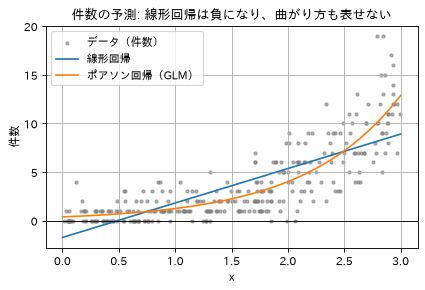

線形回帰が負の件数を予測した割合: 0.167
ポアソン回帰の予測の最小値: 0.396


In [13]:
rng = np.random.RandomState(0)
x_c = rng.uniform(0, 3, 300)
counts = rng.poisson(np.exp(-1 + 1.2 * x_c))    # 件数（x が大きいほど急に増える）

ols_c = lm.LinearRegression().fit(x_c[:, None], counts)
pois_c = lm.PoissonRegressor(alpha=0).fit(x_c[:, None], counts)

grid = np.linspace(0, 3, 100)[:, None]
plt.scatter(x_c, counts, s=8, c="gray", alpha=0.6, label="データ（件数）")
plt.plot(grid, ols_c.predict(grid), label="線形回帰")
plt.plot(grid, pois_c.predict(grid), label="ポアソン回帰（GLM）")
plt.axhline(0, color="black", lw=0.8); plt.xlabel("x"); plt.ylabel("件数")
plt.legend(); plt.title("件数の予測: 線形回帰は負になり、曲がり方も表せない"); plt.show()

print("線形回帰が負の件数を予測した割合:", (ols_c.predict(x_c[:, None]) < 0).mean().round(3))
print("ポアソン回帰の予測の最小値:", pois_c.predict(x_c[:, None]).min().round(3))

👀 線形回帰は x が小さいところで**マイナスの件数**を予測し（学習データの 2 割近く）、x が大きいところの急な増え方も表せていません。ポアソン回帰は、予測が必ず正で、指数的な増え方にも沿っています。

問題は 2 つありました。

1. 予測値が**取りうる範囲**（件数は 0 以上）を守れない → **リンク関数**で解決
2. ばらつき方が正規分布と違う（件数が大きいほどばらつきも大きい）→ **分布（損失関数）**を変えて解決

この 2 つをまとめて扱えるようにしたのが GLM です。

### 📖 ガイドの解説

一般化線形モデル（GLM）は、線形モデルを 2 つの方向に拡張します。

**1 つ目**: 予測値 $\hat{y}$ を、入力の線形結合 $Xw$ に**逆リンク関数** $h$ を通したものとします。

$$\hat{y}(w, X) = h(Xw)$$

**2 つ目**: 二乗誤差の損失を、指数型分布族（正確には再生型指数分散モデル EDM）の**単位逸脱度** $d$ に置き換えます。最小化する問題は次のとおりです（$\alpha$ は L2 正則化の強さ。サンプル重みがあれば加重平均になります）。

$$\min_{w} \frac{1}{2 n_\text{samples}} \sum_i d(y_i, \hat{y}_i) + \frac{\alpha}{2} \|w\|_2^2$$

> 📚 **用語**
> - **リンク関数 / 逆リンク関数**: 予測したい量（平均）と線形結合 $Xw$ を結びつける関数。「$Xw$ から予測値へ」の向きが逆リンク関数 $h$、その逆向きがリンク関数。例: log リンクなら、リンク関数は $\log$、逆リンク関数は $\exp$。
> - **指数型分布族**: 正規・ポアソン・ガンマ・ベルヌーイなど、共通の数式の形で書ける確率分布のグループ。この共通の形のおかげで、GLM は 1 つの枠組みで扱える。
> - **逸脱度（deviance）**: 「完全にデータに合うモデル」と比べて、今のモデルの当てはまりがどれだけ悪いかを測る量。**単位逸脱度**はその 1 サンプル分。正規分布では二乗誤差になる。

### 🔢 数式を読む

$$\hat{y}(w, X) = h(Xw)$$

**日本語で読むと**: いつもの線形結合 $Xw$ を計算し、それを関数 $h$ に通して予測値にする。$h = \exp$ なら、予測値は必ず正になる。

$$\min_{w} \frac{1}{2 n_\text{samples}} \sum_i d(y_i, \hat{y}_i) + \frac{\alpha}{2} \|w\|_2^2$$

| 記号 | 意味 |
|---|---|
| $d(y_i, \hat{y}_i)$ | サンプル $i$ の単位逸脱度（分布に合った誤差の測り方） |
| $\frac{1}{2 n_\text{samples}} \sum_i$ | 全サンプルの平均（の半分） |
| $\frac{\alpha}{2} \|w\|_2^2$ | Ridge と同じ L2 正則化。`alpha` で強さを決める |

**日本語で読むと**: 分布に合った誤差（逸脱度）の平均と、係数の大きさの罰の合計を最小にする。二乗誤差を逸脱度に取り替えた Ridge 回帰、と見ることができる。

代表的な分布と単位逸脱度:

| 分布 | 目的変数の範囲 | 単位逸脱度 $d(y, \hat{y})$ |
|---|---|---|
| 正規（Normal） | $(-\infty, \infty)$ | $(y - \hat{y})^2$ |
| ベルヌーイ（Bernoulli） | $\{0, 1\}$ | $2\left(y \log\frac{y}{\hat{y}} + (1 - y) \log\frac{1 - y}{1 - \hat{y}}\right)$ |
| カテゴリカル（Categorical） | $\{0, 1, \dots, k\}$ | $2 \sum_{i} I(y = i) \log\frac{I(y = i)}{\hat{I}(y = i)}$ |
| ポアソン（Poisson） | $[0, \infty)$ | $2\left(y \log\frac{y}{\hat{y}} - y + \hat{y}\right)$ |
| ガンマ（Gamma） | $(0, \infty)$ | $2\left(\log\frac{\hat{y}}{y} + \frac{y}{\hat{y}} - 1\right)$ |
| 逆ガウス（Inverse Gaussian） | $(0, \infty)$ | $\frac{(y - \hat{y})^2}{y \hat{y}^2}$ |

ベルヌーイ分布は、2 つの排他的な結果しかない試行（ベルヌーイ試行）をモデル化する離散分布です。カテゴリカル分布はそれを一般化したもので、$K$ 通りのカテゴリのどれかを取り、各カテゴリの確率を個別に指定します。

ガイドの図は、ポアソン分布・Tweedie 分布（power=1.5）・ガンマ分布の確率密度を示しています。ポアソンと Tweedie は $Y = 0$ に確率の塊（点質量）を持ちますが、ガンマは目的変数が厳密に正なので持ちません。

### 💡 補足: 単位逸脱度は「分布に合った誤差の測り方」

正規分布の単位逸脱度は、ちょうど二乗誤差です。つまり**普通の線形回帰は「正規分布の GLM」**です。ポアソン分布の逸脱度は、予測が 100 のときの誤差 10 より、予測が 2 のときの誤差 10 をずっと重く見ます。件数のばらつきは平均が大きいほど大きくなる、という性質に合った測り方です。

### 📖 分布の選び方

- 目的変数が**件数**（0 以上の整数）または**相対頻度**（0 以上）→ ポアソン分布 + log リンク
- 目的変数が**正の値で、右に裾が長い**（歪んでいる）→ ガンマ分布 + log リンク
- ガンマ分布より**さらに裾が重い** → 逆ガウス分布（または、より分散の冪が大きい Tweedie 族）
- 目的変数が**確率** → ベルヌーイ分布。ロジットリンク付きのベルヌーイ分布は 2 値分類に、ソフトマックスリンク付きのカテゴリカル分布は多クラス分類に使える

**📖 使用例（Examples of use cases）**

| 分野 | 件数（ポアソン） | 1 回あたりの量（ガンマ） | 年間の合計（Tweedie） |
|---|---|---|---|
| 農業・気象 | 年間の降雨回数 | 1 回の降雨量 | 年間降水量 |
| 保険の料率設定 | 契約者 1 人・1 年あたりの請求件数 | 1 件あたりの損害額 | 契約者 1 人・1 年あたりの総損害額 |
| 予知保全 | 年間の生産停止回数 | 1 回の停止時間 | 年間の総停止時間 |

そのほか、ローン返済不能の確率・送金が不正である確率・治療が効く確率や副作用が出る確率（ベルヌーイ）、ニュース記事の 3 分類（ビジネス / 政治 / エンタメ）（カテゴリカル）など。

### 🎯 なぜ使うのか

- 目的変数の性質（0 以上、正の値のみ、0 か 1 か）を**予測値が必ず守る**ようにできる。
- 「件数は平均が大きいほどばらつく」「金額は大きいほど誤差も大きい」といった、**ばらつき方の性質**を損失関数に反映できる。
- 係数の解釈がしやすい。log リンクなら、係数は「特徴が 1 増えたとき予測が $e^{w}$ **倍**になる」という、掛け算の効果を表す。

### 🕰️ 歴史（参考情報）

- **1837 年**: フランスの数学者**ポアソン**が、まれな出来事の回数を表す分布（ポアソン分布）を発表しました。1898 年には**ボルトキーヴィッチ**が、プロイセン陸軍で馬に蹴られて死亡した兵士の数がポアソン分布によく合うことを示した例が有名です。
- **1972 年**: **ネルダーとウェダーバーン**（Nelder & Wedderburn）が、論文 *Generalized Linear Models*（JRSS A）で、正規・ポアソン・二項などの回帰を 1 つの枠組みにまとめました。ガイドの参考文献のマッカラーとネルダーの教科書（1989 年）は、その集大成です。
- **1984 年**: 統計学者**トゥイーディー（M. C. K. Tweedie）**の研究に基づいて、分散が平均の冪（べき）に比例する分布の族が「Tweedie 分布」と呼ばれるようになりました。

### 1.1.12.1 使い方

📖 `TweedieRegressor` は Tweedie 分布の GLM を実装しており、`power` を変えるだけで上の分布を表せます。

| `power` | 分布 | 専用のクラス |
|---|---|---|
| 0 | 正規分布 | （`Ridge` や `ElasticNet` のほうが一般に適切） |
| 1 | ポアソン分布 | `PoissonRegressor`（`TweedieRegressor(power=1, link='log')` と厳密に同じ） |
| 2 | ガンマ分布 | `GammaRegressor`（`TweedieRegressor(power=2, link='log')` と厳密に同じ） |
| 3 | 逆ガウス分布 | — |

リンク関数は `link` 引数で指定します。

### 🔢 数式を読む: `power` の意味

Tweedie 分布は、**分散が平均の `power` 乗に比例する**分布の族です。

$$\operatorname{Var}[Y] \propto \mu^{\text{power}}$$

| `power` | 分散と平均の関係 | 分布 |
|---|---|---|
| 0 | 分散は平均に関係なく一定 | 正規分布 |
| 1 | 分散は平均に比例 | ポアソン分布 |
| 1〜2 | その間 | 複合ポアソン・ガンマ分布（0 を多く含む正の値） |
| 2 | 分散は平均の二乗に比例（標準偏差が平均に比例） | ガンマ分布 |
| 3 | 分散は平均の三乗に比例 | 逆ガウス分布 |

**日本語で読むと**: `power` が大きいほど「値が大きいところほど、ばらつきが急に大きくなる」データに向いている。

### 🧪 やってみよう: ガイドのコード例と、専用クラスとの同値性

In [14]:
from sklearn.linear_model import TweedieRegressor
reg = TweedieRegressor(power=1, alpha=0.5, link='log')
reg.fit([[0, 0], [0, 1], [2, 2]], [0, 1, 2])
print("coef_ =", reg.coef_, "/ intercept_ =", reg.intercept_)
assert np.allclose(reg.coef_, [0.2463, 0.4337], atol=1e-4)     # ガイドの出力と一致
assert np.isclose(reg.intercept_, -0.7638, atol=1e-4)

pr = lm.PoissonRegressor(alpha=0.5).fit([[0, 0], [0, 1], [2, 2]], [0, 1, 2])
print("PoissonRegressor と係数が一致:", np.allclose(pr.coef_, reg.coef_))

coef_ = [0.2463 0.4337] / intercept_ = -0.7638091359123443


PoissonRegressor と係数が一致: True


### 📖 実用上の注意（Practical considerations）

1. 特徴行列 `X` は、学習前に**標準化**しておきます。正則化が各特徴を平等に扱うようにするためです。
2. 線形予測子 $Xw$ は負にもなりますが、ポアソン・ガンマ・逆ガウス分布は負の値を取れません。そのため、非負を保証する逆リンク関数が必要です。たとえば `link='log'` なら、逆リンク関数は $h(Xw) = \exp(Xw)$ で、必ず正になります。
3. **相対頻度**（時間や量などの**曝露量（exposure）**あたりの件数）をモデル化したいときは、ポアソン分布で、目的変数を $y = \text{件数} / \text{曝露量}$、サンプルの重みを曝露量にします。
4. `TweedieRegressor` の `power` を交差検証で選ぶときは、**`scoring` を明示的に指定**します。既定のスコア `TweedieRegressor.score` 自体が `power` によって変わるので、異なる `power` どうしを公平に比べられないからです。

### 💡 補足: 曝露量（exposure）とは

保険で「1 年契約の人が 2 件請求」と「1 か月契約の人が 2 件請求」は、同じ 2 件でも危険度がまったく違います。そこで「**期間あたりの件数**」を予測したいのですが、期間の短い契約は情報が少ないので、その分だけ**重みを軽く**します。これが注意 3 の意味です。

### 🧪 やってみよう: 曝露量を正しく扱うと、真の値を復元できるか

In [15]:
rng = np.random.RandomState(2)
x_e = rng.randn(500, 1)
exposure = rng.uniform(0.2, 2.0, 500)                        # 契約期間（年）
claims = rng.poisson(exposure * np.exp(0.5 + 0.8 * x_e[:, 0]))  # 真の年間頻度 = exp(0.5 + 0.8x)

right = lm.PoissonRegressor(alpha=1e-8).fit(x_e, claims / exposure, sample_weight=exposure)
wrong = lm.PoissonRegressor(alpha=1e-8).fit(x_e, claims)      # 期間を無視して件数をそのまま予測

pd.DataFrame({"真の値": [0.5, 0.8],
              "y=件数/期間, 重み=期間": [right.intercept_, right.coef_[0]],
              "期間を無視": [wrong.intercept_, wrong.coef_[0]]},
             index=["intercept_", "coef_"])

,真の値,"y=件数/期間, 重み=期間",期間を無視
intercept_,0.5,0.4887,0.5647
coef_,0.8,0.7844,0.7320


👀 ガイドのやり方（件数 ÷ 期間を目的変数にし、期間を重みにする）では、真の値 0.5 と 0.8 に近い値が得られました。

期間を無視すると、切片も係数も真の値から離れました。

- 切片は「1 年あたり」ではなく「平均的な契約 1 件あたり」の件数を表すものになり、上にずれます（契約期間の平均は約 1.1 年）。
- 契約期間のばらつきがノイズとして上乗せされるので、係数の推定も不安定になります（ここでは 0.73）。

「何あたりの件数を予測したいのか」を決めて、曝露量を正しく渡すことが大切です。

---
## 3. 確率的勾配降下法 SGD（1.1.13 Stochastic Gradient Descent）

**ねらい**: データを少しずつ見ながら学習する方法を知り、パーセプトロンとの関係をつかむ。

### 📖 ガイドの解説

確率的勾配降下法（SGD）は、線形モデルを当てはめる、単純でとても効率の良い方法です。サンプル数（と特徴数）が非常に大きいときに特に役立ちます。`partial_fit` メソッドを使うと、**オンライン学習**や、メモリに乗りきらないデータの学習（**out-of-core 学習**）ができます。

`SGDClassifier` と `SGDRegressor` は、さまざまな（凸な）損失関数と正則化で、分類・回帰の線形モデルを当てはめます。たとえば `SGDClassifier` は、`loss="log_loss"` ならロジスティック回帰、`loss="hinge"` なら線形サポートベクターマシン（SVM）を当てはめます。詳しくは 1.5 節（SGD 専用の節）で扱います。

> 📚 **用語**
> - **オンライン学習**: データが 1 件（または少し）ずつ届くたびに、モデルを少しずつ更新していく学習方法。
> - **out-of-core 学習**: メモリ（RAM）に乗りきらない大きなデータを、ファイルなどから少しずつ読み込みながら学習すること。
> - **凸（convex）な損失関数**: お椀のような形で、谷底が 1 つしかない関数。どこから下り始めても同じ谷底に着くので、最適化が安定する。
> - **ヒンジ損失**: 線形サポートベクターマシン（1.4 節）で使う損失。正しく、かつ余裕（マージン）を持って分類できていれば 0 になる。
> - **学習率**: 1 歩で係数をどれだけ動かすかの大きさ。大きすぎると谷底を飛び越えて暴れ、小さすぎるとなかなか着かない。
> - **エポック**: 学習データ全体を 1 周すること。

### 💡 補足: 「確率的」勾配降下法とは

山の上から谷底（損失が最小の点）へ下りる場面を考えます。

- **普通の勾配降下法**: 毎回**全データ**を見て、いちばん急な下り方向を正確に計算してから 1 歩進む。正確だが 1 歩が重い
- **確率的勾配降下法**: **1 件（または少数）のデータだけ**を見て、だいたいの下り方向に 1 歩進む。方向はふらつくが、1 歩が軽いので、たくさん歩けば谷底付近に着く

データが 1 億件あっても 1 歩の計算量が変わらないのが強みです。また、新しいデータが届くたびに `partial_fit` で少しずつ学習を進められます。

### 🎯 なぜ使うのか / 🏭 利用例 / 🕰️ 歴史（参考情報）

- 🎯 1 歩の計算量がデータの総数に依存しないので、**数百万〜数十億件**のデータでも学習できます。データを全部メモリに載せる必要もありません。今日の深層学習（ニューラルネットワーク）の学習も、基本的にこの方法の仲間です。
- 🏭 大量の文書の分類（スパム判定、ニュースのカテゴリ分け）、Web 広告のクリック予測、センサーやログのストリームデータのオンライン学習など。
- 🕰️ **1951 年**に**ロビンスとモンロー**（Robbins & Monro）が、ノイズの入った観測から少しずつ答えに近づく「確率近似法」を発表したのが起源とされます。2000 年代後半以降、**レオン・ボトゥ**らの研究によって、大規模な機械学習での実用性が広く認められるようになりました。

### 🧪 やってみよう: データを少しずつ与えて学習する（partial_fit）

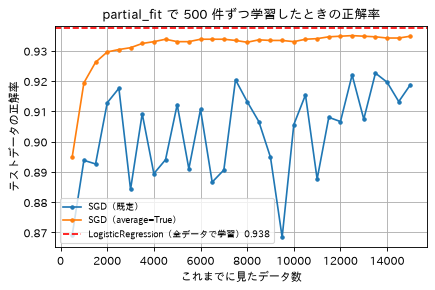

,最後の正解率,5000 件以降の最低値
SGD（既定）,0.9188,0.8684
SGD（average=True）,0.9348,0.9328


In [16]:
X_big, y_big = make_classification(n_samples=20_000, n_features=20, n_informative=5, random_state=0)
X_big = (X_big - X_big.mean(0)) / X_big.std(0)               # SGD はスケールに敏感なので標準化
X_tr, y_tr, X_te, y_te = X_big[:15_000], y_big[:15_000], X_big[15_000:], y_big[15_000:]

curves = {}
for label, kw in [("SGD（既定）", {}), ("SGD（average=True）", dict(average=True))]:
    sgd = lm.SGDClassifier(loss="log_loss", random_state=0, **kw)
    seen, acc = [], []
    for start in range(0, 15_000, 500):                       # 500 件ずつ届くと想定
        sgd.partial_fit(X_tr[start:start + 500], y_tr[start:start + 500], classes=[0, 1])
        seen.append(start + 500); acc.append(sgd.score(X_te, y_te))
    curves[label] = acc
    plt.plot(seen, acc, marker=".", label=label)

full = lm.LogisticRegression().fit(X_tr, y_tr).score(X_te, y_te)
plt.axhline(full, color="red", ls="--", label=f"LogisticRegression（全データで学習）{full:.3f}")
plt.xlabel("これまでに見たデータ数"); plt.ylabel("テストデータの正解率")
plt.legend(fontsize=8); plt.title("partial_fit で 500 件ずつ学習したときの正解率"); plt.show()
pd.DataFrame({k: {"最後の正解率": v[-1], "5000 件以降の最低値": min(v[9:])} for k, v in curves.items()}).T

### 👀 結果の読み方

- **既定の SGD**（青）は、正解率が上下に大きく揺れ続け、全データで学習したロジスティック回帰（赤い点線）に届いていません。1 歩ごとに「目の前の 500 件」に引っ張られるためです。
- **`average=True`**（オレンジ）は、これまでの係数の**平均**を使う「平均化 SGD」です。揺れがほとんど消え、全データ学習とほぼ同じ正解率まで安定して上がりました。
- どちらも、一度に全データをメモリに載せる必要がありません。データが大きいときや、データが次々に届くときに向いています。

> ⚠️ **つまずきポイント**:
> - `partial_fit` の**最初の呼び出し**では、`classes=` で全クラスを教える必要があります（最初のかたまりに全クラスが含まれているとは限らないため）。
> - SGD は特徴のスケールに敏感です。上のコードでは標準化しています。
> - 上の図のとおり、既定の設定のままだと、厳密に解くソルバより精度が落ちたり不安定になったりします。ガイドが「調整が必要」と書いているのはこのためです（`average`、学習率、`alpha`、反復回数など。1.5 節で詳しく扱います）。

### 1.1.13.1 パーセプトロン（Perceptron）

📖 `Perceptron` も、大規模学習に向いた単純な分類アルゴリズムで、SGD から派生したものです。既定では次の性質を持ちます。

- 学習率を必要としない
- 正則化しない
- **間違えたときだけ**モデルを更新する

最後の性質から、パーセプトロンはヒンジ損失の SGD より少し速く学習でき、得られるモデルもよりスパースになります。実際、`Perceptron` は「パーセプトロン損失」と「一定の学習率」を指定した `SGDClassifier` の**ラッパー**です。

### 🕰️ 歴史 / 🏭 利用例（参考情報）

- **1958 年**: 心理学者**フランク・ローゼンブラット**が、脳の神経細胞をまねた学習する機械として**パーセプトロン**を発表しました。専用のハードウェア（Mark I Perceptron）も作られ、大きな期待を集めました。
- **1969 年**: **ミンスキーとパパート**が著書『Perceptrons』で、1 層のパーセプトロンでは XOR のような単純な問題も解けないことを示しました。これが第 1 次の「AI の冬」の一因になったといわれます（XOR は 4/4 のノートで実際に試します）。
- その後、パーセプトロンを何層も重ねた多層パーセプトロン（1.17 節のニューラルネットワーク）へと発展しました。
- 🏭 今日では、単独で使うよりも、オンライン学習の最も単純な例として、また線形分類の考え方を学ぶ教材として登場することが多いアルゴリズムです。

### 🧪 やってみよう: 本当に SGDClassifier のラッパーか

In [17]:
p = lm.Perceptron(random_state=0, shuffle=False).fit(X_tr, y_tr)
s = lm.SGDClassifier(loss="perceptron", learning_rate="constant", eta0=1, penalty=None,
                     random_state=0, shuffle=False).fit(X_tr, y_tr)
print("係数が完全に一致:", np.array_equal(p.coef_, s.coef_))
print("正解率  Perceptron:", round(p.score(X_te, y_te), 3), "/ SGD(loss='hinge'):",
      round(lm.SGDClassifier(loss="hinge", random_state=0).fit(X_tr, y_tr).score(X_te, y_te), 3))

係数が完全に一致: True
正解率  Perceptron: 0.904 / SGD(loss='hinge'): 0.936


👀 係数は完全に一致しました。`Perceptron` は独自の実装ではなく、設定済みの `SGDClassifier` です。

💡 **パーセプトロン損失とヒンジ損失の違い**: パーセプトロンは「正しく分類できていれば更新しない」、ヒンジ損失（線形 SVM）は「正しくても境界に近すぎれば更新する」。ヒンジ損失は**余裕（マージン）**を持って分類しようとするので、多くの場合、未知データに強くなります。

### 1.1.13.2 Passive Aggressive アルゴリズム

📖 Passive Aggressive（PA）アルゴリズムは、大規模なオンライン学習のための 2 つのアルゴリズム（PA-I と PA-II）で、SGD から派生しています。パーセプトロンと同じく学習率を必要としませんが、パーセプトロンと違って正則化パラメータ `eta0`（元論文の $C$）を持ちます。

- 分類: PA-I は `SGDClassifier(loss="hinge", penalty=None, learning_rate="pa1", eta0=1.0)`、PA-II は `learning_rate="pa2"`
- 回帰: PA-I は `SGDRegressor(loss="epsilon_insensitive", penalty=None, learning_rate="pa1", eta0=1.0)`、PA-II は `learning_rate="pa2"`

### 💡 補足: 名前の意味

- **Passive（受け身）**: 正しく分類できていれば（損失が 0 なら）何もしない
- **Aggressive（積極的）**: 間違えたら、**その 1 件を正しく分類できるところまで**一気に係数を動かす（ただし `eta0` で動かす量に上限をかける）

🕰️ **歴史（参考情報）**: 2006 年に**クラマー（Koby Crammer）ら**が、論文 *Online Passive-Aggressive Algorithms*（JMLR、ガイドの参考文献）で発表しました。🏭 データが次々に届くオンラインの文書分類（スパムフィルタなど）で、学習率を調整しなくても安定して学習できる方法として使われてきました。

In [18]:
for lr in ["pa1", "pa2"]:
    pa = lm.SGDClassifier(loss="hinge", penalty=None, learning_rate=lr, eta0=1.0, random_state=0).fit(X_tr, y_tr)
    print(f"learning_rate={lr!r}: テスト正解率 {pa.score(X_te, y_te):.3f}")

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    lm.PassiveAggressiveClassifier(random_state=0).fit(X_tr, y_tr)
print("\n旧クラス PassiveAggressiveClassifier を使うと:",
      [str(w.message)[:120] + "..." for w in caught if w.category is FutureWarning])

learning_rate='pa1': テスト正解率 0.914
learning_rate='pa2': テスト正解率 0.914

旧クラス PassiveAggressiveClassifier を使うと: ['Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGD...']


> ⚠️ **つまずきポイント（バージョンによる違い）**: 以前は専用のクラス `PassiveAggressiveClassifier` / `PassiveAggressiveRegressor` を使うのが一般的でした。1.8 で非推奨になり、1.10 で削除される予定です。上のように `SGDClassifier(learning_rate="pa1")` などで書きます。

---
## 4. まとめ

### 手法の比較表

| 手法 | 目的変数 | ポイント |
|---|---|---|
| `LogisticRegression` | クラス（2 値・多クラス） | 直線の出力をシグモイド / ソフトマックスで確率に変換。正則化は既定で有効、強さは `C`（大きいほど弱い） |
| `LogisticRegressionCV` | 同上 | `C` と `l1_ratio` を交差検証で選ぶ |
| `PoissonRegressor` | 件数・頻度（0 以上） | log リンクで予測が必ず正 |
| `GammaRegressor` | 正の値で右に裾が長い（金額、時間） | 同上 |
| `TweedieRegressor` | 上をまとめて表現（`power` で選ぶ） | 0 を多く含む正の値（年間損害額など）にも対応 |
| `SGDClassifier` / `SGDRegressor` | 分類 / 回帰 | 大規模・逐次データ。`partial_fit` で少しずつ学習。調整が必要 |
| `Perceptron` | 分類 | 間違えたときだけ更新する SGD |

### 覚えておきたい 3 つのこと

1. **ロジスティック回帰は分類器**。`C` は正則化の「逆」の強さで、`alpha` と向きが反対。
2. **目的変数の性質に合わせて GLM を選ぶ**。件数ならポアソン、正の金額ならガンマ。普通の線形回帰は「正規分布の GLM」にすぎない。
3. **ソルバは表で選ぶ**。対応していない組み合わせはエラーになるので、黙って間違うことはない。

### 🧩 ドメインモデルの視点

- `Perceptron` が `SGDClassifier` の設定済みラッパーであったり、`PoissonRegressor` が `TweedieRegressor(power=1)` と同じだったりと、scikit-learn は「**よく使う設定に名前を付けたクラス**」を用意しています。TypeScript / Java なら、ファクトリメソッドや、既定値を埋めたサブクラスに相当します。
- `OneVsRestClassifier(LogisticRegression(...))` は、Estimator を**包んで**別の Estimator にするメタ推定器（Decorator / Composite パターン）の実例です。
- `penalty` の非推奨化や `PassiveAggressiveClassifier` の廃止予定のように、API は変わっていきます。古い記事のコードが警告を出したら、警告文の指示に従うのが近道です。

### ✅ 確認クイズ

**Q1.** `LogisticRegression` で正則化を**弱く**したいとき、`C` を大きくしますか、小さくしますか。

<details><summary>答え</summary>

大きくします。`C` はコスト関数で正則化項の分母にあるので、大きいほど正則化が弱くなります。`C=np.inf` で正則化なしです。
</details>

**Q2.** Elastic-Net 正則化のロジスティック回帰を使いたいとき、ソルバは何を選びますか。

<details><summary>答え</summary>

`saga`。Elastic-Net（0 < `l1_ratio` < 1）に対応する唯一のソルバです。
</details>

**Q3.** 保険契約ごとの「年間の請求件数」を予測したい。契約期間はまちまちです。どうモデル化しますか。

<details><summary>答え</summary>

`PoissonRegressor` で、目的変数を「件数 ÷ 契約期間（年）」、`sample_weight` を契約期間にします。
</details>

**Q4.** `partial_fit` を初めて呼ぶとき、忘れてはいけない引数は何ですか。

<details><summary>答え</summary>

`classes=`（分類の場合）。最初のデータのかたまりに全クラスが含まれているとは限らないので、全クラスを先に教えます。
</details>

---
**前のノート**: [2/4 特徴選択とベイズ回帰](./01_linear_models_2_selection_bayes.ipynb) ・ **次のノート**: [4/4 頑健な回帰と拡張](./01_linear_models_4_robust_poly.ipynb) — ロバスト回帰, 分位点回帰, 多項式回帰